In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import ttest_ind
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# 한글 폰트 설정 (Windows 기준)
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 경로 설정 (사용자 환경에 맞게 수정)
DATA_PATH = '../CMAPSSData/'

print("✅ 환경 설정 및 라이브러리 로드 완료")

✅ 환경 설정 및 라이브러리 로드 완료


In [27]:
def load_cmapss_data(data_id='FD001'):
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
    test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
    rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])
    
    return train, test, rul

# 테스트: FD001 로드
df_train, df_test, df_rul = load_cmapss_data('FD001')
print(f" FD001 로드 완료: Train {df_train.shape}, Test {df_test.shape}")

 FD001 로드 완료: Train (20631, 26), Test (13096, 26)


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_10256\1173472508.py:4: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_10256\1173472508.py:5: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_10256\1173472508.py:6: SyntaxWarning: invalid escape sequence '\s'
  rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])


# 데이터 전처리 후 csv로 저장했으면 아래는 안해도됨

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler

# 1. 환경 설정 및 데이터 로드
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="white", font='Malgun Gothic')

# 데이터 로드 함수 (DATA_PATH는 본인 환경에 맞게 정의되어 있어야 합니다)
def load_cmapss_data(data_id='FD001'):
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
    test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
    rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])
    return train, test, rul

df_train, df_test, df_rul = load_cmapss_data('FD001')

# 단계별 데이터 보관용 리스트 및 센서 설정
steps = []
sensor_names = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

# ---------------------------------------------------------
# [Step 1] 원본 데이터 저장
# ---------------------------------------------------------
steps.append(df_train.copy())

# ---------------------------------------------------------
# [Step 2] 상수 제거 & RUL Capping
# ---------------------------------------------------------
df_train['max_cycle'] = df_train.groupby('unit_nr')['time_cycles'].transform('max')
df_train['RUL'] = (df_train['max_cycle'] - df_train['time_cycles']).clip(upper=120)
df_train.drop(columns=['max_cycle'], inplace=True)

const_cols = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
df_train = df_train.drop(columns=const_cols)
df_test = df_test.drop(columns=const_cols)

steps.append(df_train.copy())

# ---------------------------------------------------------
# [Step 3] 가우시안 스무딩 (팀원 코드 스타일 적용)
# ---------------------------------------------------------
active_sensors = [c for c in df_train.columns if c.startswith('s_')]
GAUSS_SIGMA = 2.0

def apply_gaussian_team_style(df, features, sigma=GAUSS_SIGMA):
    # 정렬 및 인덱스 리셋 ㅋ
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    
    # 루프를 통한 엔진별 처리
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            # 팀원 스타일: mode='nearest' 적용으로 끝단 왜곡 방지
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

df_train = apply_gaussian_team_style(df_train, active_sensors)
df_test = apply_gaussian_team_style(df_test, active_sensors)

steps.append(df_train.copy())

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
C:\Users\yesyo\AppData\Local\Temp\ipykernel_10256\3915158896.py:16: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f'{DATA_PATH}train_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_10256\3915158896.py:17: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f'{DATA_PATH}test_{data_id}.txt', sep='\s+', header=None, names=cols)
C:\Users\yesyo\AppData\Local\Temp\ipykernel_10256\3915158896.py:18: SyntaxWarning: invalid escape sequence '\s'
  rul = pd.read_csv(f'{DATA_PATH}RUL_{data_id}.txt', sep='\s+', header=None, names=['RUL'])


In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. 정렬 기준 설정: 엔진(unit_nr)별로 묶고, 그 안에서 시간순(cycle) 정렬
df_train = df_train.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
df_test = df_test.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)

# 2. 파생변수를 만들 센서 정의
base_features = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
setting_features = ['setting_1', 'setting_2', 'setting_3']
y_label = 'RUL'

# 3. 이동평균(MA) & 차분(diff) 생성 함수
def add_features(df, features, window=5):
    df_res = df.copy()
    for col in features:
        # 엔진별로 그룹화하여 순서대로 계산
        group = df_res.groupby('unit_nr')[col]
        
        # 이동평균 추가
        df_res[f'{col}_ma'] = group.transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        
        # 차분(변화량) 추가
        df_res[f'{col}_diff'] = group.transform(lambda x: x.diff().fillna(0))
        
    return df_res

# 4. 데이터프레임 업데이트
df_train = add_features(df_train, base_features)
df_test = add_features(df_test, base_features)

# 5. 최종 피처 리스트 (원본 + 세팅 + MA + diff = 총 45개 정도)
X_features_full = base_features + setting_features + \
                [f'{c}_ma' for c in base_features] + \
                  [f'{c}_diff' for c in base_features]

# 6. 데이터셋 분리
unit_ids = df_train['unit_nr'].unique()
train_units, val_units = train_test_split(unit_ids, test_size=0.2, random_state=42)

train_set = df_train[df_train['unit_nr'].isin(train_units)].copy()
val_set = df_train[df_train['unit_nr'].isin(val_units)].copy()
test_set = df_test.copy()

# ---------------------------------------------------------
# [Step 4 반영] MinMax 정규화 (Train에만 fit, Val/Test는 transform)
# ---------------------------------------------------------
scaler = MinMaxScaler()

# Train 데이터로 모든 피처 기준점 학습 (fit)
train_set[X_features_full] = scaler.fit_transform(train_set[X_features_full])

# 학습된 기준점으로 Val, Test 데이터 변환 (transform)
val_set[X_features_full] = scaler.transform(val_set[X_features_full])
test_set[X_features_full] = scaler.transform(test_set[X_features_full])

# 최종 변수 할당 
X_train = train_set[X_features_full]
y_train = train_set[y_label]

X_val = val_set[X_features_full]
y_val = val_set[y_label]

# 테스트 세트는 각 엔진의 마지막 시점 추출 
X_test = test_set.reset_index(drop=True).groupby('unit_nr').last()[X_features_full]
y_test = df_rul['RUL'].values

print(" [최종 데이터 분리 통계 - 정렬 및 42+α 피처 반영]")
print(f" 총 피처 수: {len(X_features_full)}개")
print(f" X_train: {X_train.shape[0]} 행 (엔진 {len(train_units)}개)")
print(f" y_train:  {y_train.shape[0]} 행 (엔진 {len(train_units)}개)")
print(f" X_val:   {X_val.shape[0]} 행 (엔진 {len(val_units)}개)")
print(f" y_val:  {X_val.shape[0]} 행 (엔진 {len(val_units)}개)")
print(f" X_test:  {X_test.shape[0]} 행 (엔진 100개)")
print(f" y_test:  {y_test.shape[0]} 행 (엔진 100개)")

 [최종 데이터 분리 통계 - 정렬 및 42+α 피처 반영]
 총 피처 수: 45개
 X_train: 16561 행 (엔진 80개)
 y_train:  16561 행 (엔진 80개)
 X_val:   4070 행 (엔진 20개)
 y_val:  4070 행 (엔진 20개)
 X_test:  100 행 (엔진 100개)
 y_test:  100 행 (엔진 100개)


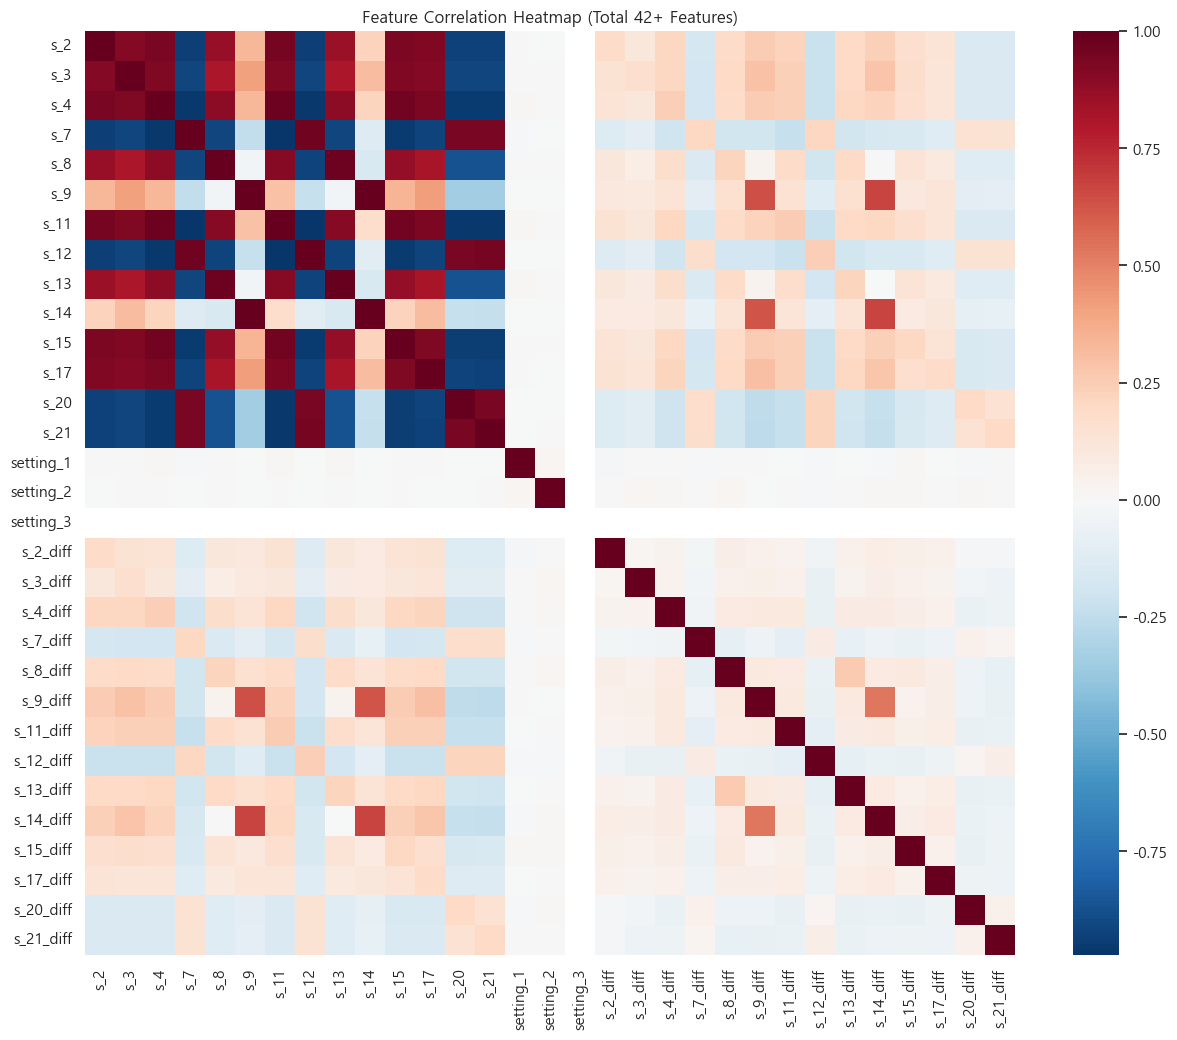

상관관계가 0.95 이상인 피처 개수: 5개
['s_11', 's_12', 's_13', 's_14', 's_15']


In [101]:
# 피처들 간의 상관계수 계산
corr_matrix = X_train.corr()

# 히트맵 시각화
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("Feature Correlation Heatmap (Total 42+ Features)")
plt.show()

# 상관관계가 0.95 이상인 쌍만 출력해보기
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"상관관계가 0.95 이상인 피처 개수: {len(to_drop)}개")
print(to_drop)

In [60]:
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_nasa_score(y_true, y_pred):
    """C-MAPSS 전용 NASA Score 계산 함수 ㅋ"""
    diff = y_pred - y_true
    # 조기 예측(diff < 0)보다 늦은 예측(diff > 0)에 더 큰 패널티 부여 
    score = np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)
    return np.sum(score)

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = calculate_nasa_score(y_true, y_pred)
    print(f"[{model_name}] 평가 결과")
    print(f" RMSE: {rmse:.4f}")
    print(f" NASA Score: {score:.4f}")
    return rmse, score

In [102]:
from sklearn.linear_model import LinearRegression

# 모델 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 예측 및 평가
y_pred_lr = lr_model.predict(X_test)
# Linear는 결과가 음수가 나올 수 있으므로 0으로 하한선 고정 ㅋ
y_pred_lr = np.maximum(y_pred_lr, 0)

lr_rmse, lr_score = evaluate_model(y_test, y_pred_lr, "Linear Regression")

[Linear Regression] 평가 결과
 RMSE: 22.8101
 NASA Score: 2048.2470


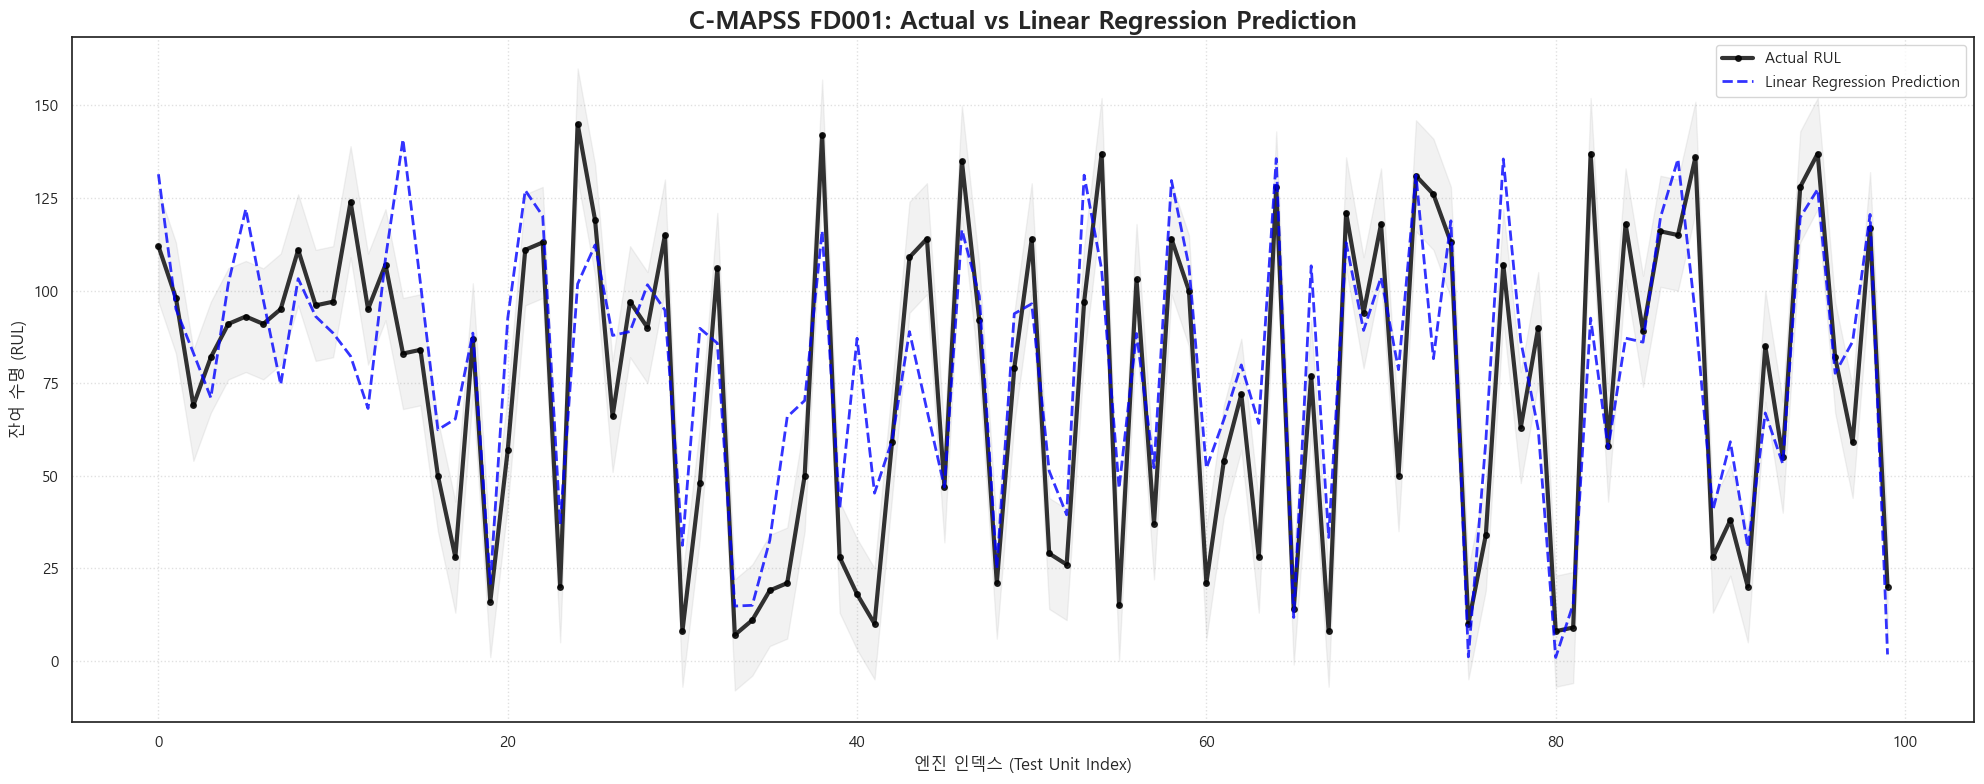

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

# 1. 실제 값 (정답)
plt.plot(y_test, 
         label='Actual RUL', 
         color='black', 
         linewidth=3, 
         marker='o', 
         markersize=4, 
         alpha=0.8)

# 2. Linear Regression 예측값
plt.plot(y_pred_lr, 
         label='Linear Regression Prediction', 
         linestyle='--', 
         color='blue',
         linewidth=2,
         alpha=0.8)

# 제목 및 라벨
plt.title('C-MAPSS FD001: Actual vs Linear Regression Prediction', 
          fontsize=18, fontweight='bold')
plt.xlabel('엔진 인덱스 (Test Unit Index)', fontsize=12)
plt.ylabel('잔여 수명 (RUL)', fontsize=12)

# 범례
plt.legend(loc='upper right', fontsize=11)

# 격자
plt.grid(True, linestyle=':', alpha=0.6)

# 오차 허용 범위 (±15)
plt.fill_between(range(len(y_test)), 
                 y_test-15, 
                 y_test+15, 
                 color='gray', 
                 alpha=0.1,
                 label='±15 Tolerance')

plt.tight_layout()
plt.show()